# [9660] Linear Regression 1

In [1]:
from datetime import datetime
print(f'Run time: {datetime.now().strftime("%D %T")}')

Run time: 10/06/26 20:11:41


### Section 1 Use simulated data to understand how we calcuate beta 0 and beta 1 in linear regression


### Import libraries

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
# import matplotlib.pyplot as plt      # Alternative method

*italicized text*### Create data

In [3]:
np.random.seed(3)

In [4]:
# 10 normally distributed random numbers (mean 0 and st dev. 1)
np.random.randn(10)

array([ 1.78862847,  0.43650985,  0.09649747, -1.8634927 , -0.2773882 ,
       -0.35475898, -0.08274148, -0.62700068, -0.04381817, -0.47721803])

In [5]:
# Generate 'random' data
np.random.seed(0)
X = 2.5 * np.random.randn(100) + 1.5   # Array of 100 X values with mean = 1.5, stddev = 2.5
res = 0.5 * np.random.randn(100)       # Generate 100 residual terms
y = 2 + 0.3 * X + res                  # Array of y values

### Setup dataframe

In [6]:
# Create pandas dataframe to store X and y values
df = pd.DataFrame(
    {'X': X,
     'y': y}
)

# Display shape of dataframe
df.shape

(100, 2)

In [7]:
# Display first five rows of dataframe
df.head()

,X,y
0,5.910131,4.714615
1,2.500393,2.076238
2,3.946845,2.548811
3,7.102233,4.615368
4,6.168895,3.264107


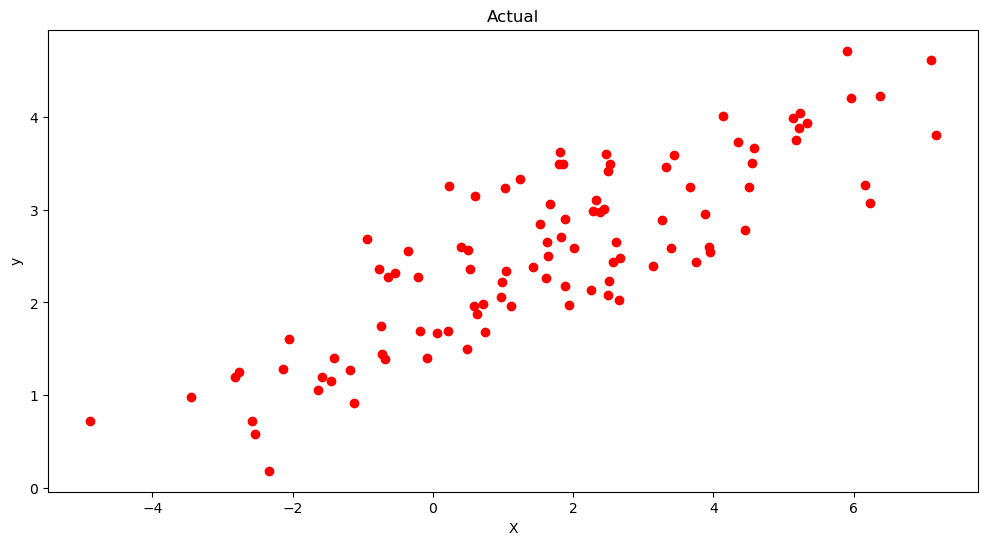

In [8]:
# Plot actual data (X and y)
plt.figure(figsize=(12, 6))
plt.plot(X, y,"ro")   # scatter plot showing actual data, 'ro' for red circles.
plt.title('Actual')
plt.xlabel('X')
plt.ylabel('y')

plt.show()

X is the independent variable  
y is the dependent variable

### Calculate linear regression - ordinary least squares using the equation we introduced in the class

In [9]:
# Calculate the mean of X and y
xmean = np.mean(X)
ymean = np.mean(y)

# Calculate the terms needed for the numerator and denominator of beta
df['xycov'] = (df['X'] - xmean) * (df['y'] - ymean)     # covariance of X and y
df['xvar'] = (df['X'] - xmean)**2                       # variance of X

# Calculate beta and alpha
beta1 = df['xycov'].sum() / df['xvar'].sum()
beta0 = ymean - (beta1 * xmean)

print(f'beta0 = {beta0}')
print(f'beta1 = {beta1}')

beta0 = 2.0031670124623426
beta1 = 0.3229396867092763


In [10]:
# Trained model
ypred = beta0 + ( beta1 * X )

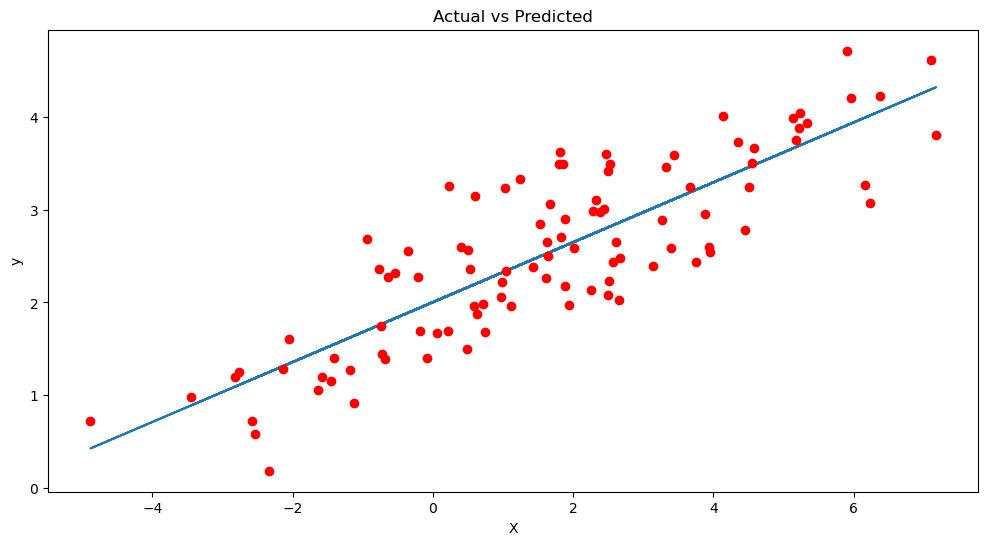

In [11]:
# Plot regression against actual data
plt.figure(figsize=(12, 6))
plt.plot(X, ypred)     # regression line, plot x and y using default line style and color
plt.plot(X, y, 'ro')   # scatter plot showing actual data, "ro" means red circle
plt.title('Actual vs Predicted')
plt.xlabel('X')
plt.ylabel('y')

plt.show()

## Section 2 Use Real Data to understand the inference and prediction in linear regression


```
# This is formatted as code
```



### Initialize global variables

In [12]:
global random_state
random_state = 42

### Import libraries

In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


### Load data
Columns
* age: age of primary beneficiary
* sex: female=0, male=1
* bmi: body mass index
* children: # of children covered by health insurance
* smoker: yes=1, no=0
* region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.
* charges: individual medical costs billed by health insurance

In [14]:
# Read data file (insurance_rates.csv) into a dataframe
df = pd.read_csv('https://raw.githubusercontent.com/vjavaly/Baruch-CIS-9660/main/data/insurance_rates.csv')

In [15]:
df

,age,gender,smoker,bmi,children,region,charges
0,19,0,1,27.900,0,southwest,16884.92400
1,18,1,0,33.770,1,southeast,1725.55230
2,28,1,0,33.000,3,southeast,4449.46200
3,33,1,0,22.705,0,northwest,21984.47061
4,32,1,0,28.880,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,0,30.970,3,northwest,10600.54830
1334,18,0,0,31.920,0,northeast,2205.98080
1335,18,0,0,36.850,0,southeast,1629.83350
1336,21,0,0,25.800,0,southwest,2007.94500


In [16]:
# !pip install statsmodels

In [17]:
import statsmodels.api as sm

In [18]:
import statsmodels.formula.api as sms

### Examine data

In [19]:
df.shape

(1338, 7)

In [20]:
df.columns

Index(['age', 'gender', 'smoker', 'bmi', 'children', 'region', 'charges'], dtype='object')

### what is IVs and what is DV? IVs are age, gender,smoker, bmi, chidren, region and DV is charges

In [21]:
df.dtypes

age           int64
gender        int64
smoker        int64
bmi         float64
children      int64
region       object
charges     float64
dtype: object

In [22]:
df.head() ## The first five observations

,age,gender,smoker,bmi,children,region,charges
0,19,0,1,27.900,0,southwest,16884.92400
1,18,1,0,33.770,1,southeast,1725.55230
2,28,1,0,33.000,3,southeast,4449.46200
3,33,1,0,22.705,0,northwest,21984.47061
4,32,1,0,28.880,0,northwest,3866.85520


In [23]:
df.tail()  ## the last five observations

,age,gender,smoker,bmi,children,region,charges
1333,50,1,0,30.97,3,northwest,10600.5483
1334,18,0,0,31.92,0,northeast,2205.9808
1335,18,0,0,36.85,0,southeast,1629.8335
1336,21,0,0,25.80,0,southwest,2007.9450
1337,61,0,1,29.07,0,northwest,29141.3603


### Prepare data for model training

In [24]:
# Drop non-numeric columns: region
df.drop('region', axis=1, inplace=True)
# axis : default 0 Whether to drop labels from the index (0 or ‘index’) or columns (1 or ‘columns’)
# inpace=True. If False, return a copy. Otherwise, do operation in place and return None.
df.head()

,age,gender,smoker,bmi,children,charges
0,19,0,1,27.900,0,16884.92400
1,18,1,0,33.770,1,1725.55230
2,28,1,0,33.000,3,4449.46200
3,33,1,0,22.705,0,21984.47061
4,32,1,0,28.880,0,3866.85520


### Separate independent and dependent variables

In [25]:
# Independent variables: All columns except 'charges'
X = df.drop('charges', axis = 1)

# Dependent variable: charges
y = df['charges']

In [26]:
X.shape

(1338, 5)

## ***Inference***

In [27]:
#Add a constant term to IV
X1 = sm.add_constant(X)
#Fit the linear regression model
model = sm.OLS(y,X1).fit()
#Print the summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     798.0
Date:                Tue, 06 Oct 2026   Prob (F-statistic):               0.00
Time:                        20:11:45   Log-Likelihood:                -13551.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1332   BIC:                         2.715e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.205e+04    951.260    -12.670      0.0

### How to interpret the regression results?

#### 1) age will have a positive and significant influence on insurance charges
#### 2) smoker will have a positive and significant influence on insurance charges compared to non-smoker (dummy)
#### 3) bmi will have a positive and significant influence on insurance charges
#### 4) chidren will have a positive and sigfnicant influence on insurance charges

## Interaction

cite: https://lost-stats.github.io/Model_Estimation/OLS/interaction_terms_and_polynomials.html

In [28]:
model1=sms.ols('charges~age+gender+smoker*bmi+children', data=df)

In [29]:
print(model1.fit().summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.839
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     1158.
Date:                Tue, 06 Oct 2026   Prob (F-statistic):               0.00
Time:                        20:11:45   Log-Likelihood:                -13255.
No. Observations:                1338   AIC:                         2.652e+04
Df Residuals:                    1331   BIC:                         2.656e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -2503.0407    839.433     -2.982      0.0

* How to interpret the results about the interaction term?

### bmi weaken the negative effect of smoker on insurance charges

## Non-Linear Relationship

In [30]:
model2=sms.ols('charges~bmi+I(bmi**2)+I(bmi**3)+age+gender+smoker+children', data=df)

In [31]:
print(model2.fit().summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     575.3
Date:                Tue, 06 Oct 2026   Prob (F-statistic):               0.00
Time:                        20:11:45   Log-Likelihood:                -13546.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1330   BIC:                         2.715e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    5727.8066   1.09e+04      0.526      

## **Prediction**

### Split data into training and test sets

In [32]:

# 70% training set, 30% test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_state)

### Train Linear Regression model

In [33]:
# Instantiate LinearRegression model
model = LinearRegression()

In [34]:
# Fit LinearRegression model
model.fit(X_train, y_train)

LinearRegression()

### Calculate model performance for training and test sets

In [35]:
# Calculate model performance for training set
y_train_predict = model.predict(X_train)
mse = mean_squared_error(y_train, y_train_predict)

print("Model performance for training set")
print("----------------------------------")
print("MSE is {}".format(round(mse,2)))


Model performance for training set
----------------------------------
MSE is 37878481.86


In [36]:
# Calculate model performance for test set
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)


print("Model performance for test set")
print("------------------------------")
print("MSE is {}".format(round(mse,2)))


Model performance for test set
------------------------------
MSE is 34003912.39


[link text](https://)### Review trained model intercept and coefficients

In [37]:
model.intercept_

np.float64(-12538.439849853145)

In [38]:
model.coef_

array([  261.91061673,   136.65119758, 23618.76182167,   333.36099462,
         432.1792927 ])

In [39]:
model.coef_[0]

np.float64(261.91061672671435)

In [40]:
min_values = X.min()
min_values

age         18.00
gender       0.00
smoker       0.00
bmi         15.96
children     0.00
dtype: float64

In [41]:
max_values = X.max()
max_values

age         64.00
gender       1.00
smoker       1.00
bmi         53.13
children     5.00
dtype: float64

In [42]:
y.max()

63770.42801

In [43]:
y.min()

1121.8739

### Execute model with new independent variable values to make prediction
Values set by professor

In [44]:
age_1 = 31
gender_1 = 1
smoker_1 = 1
bmi_1 = 30
children_1 = 2

predicted_charges = model.intercept_ + ( model.coef_[0] * age_1 ) + (model.coef_[1] * gender_1 ) + \
        (model.coef_[2] * smoker_1 ) + (model.coef_[3] * bmi_1 ) + (model.coef_[4] * children_1 )
print('Predicted charges =', round(predicted_charges,2))

Predicted charges = 30201.39


In [45]:
age_2 = 46
gender_2 = 0
smoker_2 = 0
bmi_2 = 23
children_2 = 1

predicted_charges = model.intercept_ + ( model.coef_[0] * age_2 ) + (model.coef_[1] * gender_2 ) + \
        (model.coef_[2] * smoker_2 ) + (model.coef_[3] * bmi_2 ) + (model.coef_[4] * children_2 )
print('Predicted charges =', round(predicted_charges,2))

Predicted charges = 7608.93
